### Ejercicio 2 - Diagnostico experimental de CPU, memoria, disco e I/O
## Objetivo. Construir un microbenchmark local en Python para observar diferencias entre operacio-
nes intensivas en CPU, memoria, almacenamiento y entrada/salida. El prop´osito es que el estudiante
conecte arquitectura computacional, jerarqu´ıa de memoria y cuellos de botella con evidencia experi-
mental.

In [2]:
from benchmark import medir, paso_nbody, crear_particulas,simulacion_nbody
from benchmark import benchmark_cpu
from benchmark import benchmark_memoria
from benchmark import benchmark_disco
from benchmark import graficar_cpu, graficar_memoria, graficar_disco
import pandas as pd

## Ejecución del benchmark CPU

Lanzamos el escenario completo del benchmark CPU (simulación N-body):

- **5 tamaños** de `N_PARTICULAS` × **8 repeticiones** = **40 mediciones**.
- Cooldown de 10 s entre repeticiones para mitigar thermal throttling.
- Cada registro contiene tiempo, memoria delta, throughput (pares/s) y la información 
  del tamaño correspondiente.

In [3]:
registros_cpu = benchmark_cpu()
df_cpu = pd.DataFrame(registros_cpu)
df_cpu


[CPU] N = 1500 partículas (1,124,250 pares de cálculos)
  rep 1/8: 0.254 s
  rep 2/8: 0.256 s
  rep 3/8: 0.247 s
  rep 4/8: 0.270 s
  rep 5/8: 0.253 s
  rep 6/8: 0.258 s
  rep 7/8: 0.244 s
  rep 8/8: 0.242 s

[CPU] N = 2000 partículas (1,999,000 pares de cálculos)
  rep 1/8: 0.412 s
  rep 2/8: 0.414 s
  rep 3/8: 0.420 s
  rep 4/8: 0.420 s
  rep 5/8: 0.421 s
  rep 6/8: 0.423 s
  rep 7/8: 0.411 s
  rep 8/8: 0.417 s

[CPU] N = 2800 partículas (3,918,600 pares de cálculos)
  rep 1/8: 0.790 s
  rep 2/8: 0.789 s
  rep 3/8: 0.797 s
  rep 4/8: 0.794 s
  rep 5/8: 0.796 s
  rep 6/8: 0.798 s
  rep 7/8: 0.787 s
  rep 8/8: 0.797 s

[CPU] N = 4000 partículas (7,998,000 pares de cálculos)
  rep 1/8: 1.590 s
  rep 2/8: 1.603 s
  rep 3/8: 1.592 s
  rep 4/8: 1.603 s
  rep 5/8: 1.593 s
  rep 6/8: 1.605 s
  rep 7/8: 1.608 s
  rep 8/8: 1.598 s

[CPU] N = 5500 partículas (15,122,250 pares de cálculos)
  rep 1/8: 3.005 s
  rep 2/8: 3.015 s
  rep 3/8: 3.038 s
  rep 4/8: 3.024 s
  rep 5/8: 3.025 s
  rep 6/8: 

,escenario,tamano_n,tamano_pares,repeticion,tiempo_s,memoria_delta_mb,throughput_pares_s
0,cpu_nbody,1500,1124250,1,0.253572,0.671875,4.433644e+06
1,cpu_nbody,1500,1124250,2,0.256127,0.531250,4.389425e+06
2,cpu_nbody,1500,1124250,3,0.246940,0.000000,4.552718e+06
3,cpu_nbody,1500,1124250,4,0.269694,0.000000,4.168613e+06
4,cpu_nbody,1500,1124250,5,0.252770,0.000000,4.447720e+06
5,cpu_nbody,1500,1124250,6,0.257756,0.000000,4.361677e+06
6,cpu_nbody,1500,1124250,7,0.244479,0.000000,4.598550e+06
7,cpu_nbody,1500,1124250,8,0.241961,0.000000,4.646410e+06
8,cpu_nbody,2000,1999000,1,0.412130,0.234375,4.850411e+06
9,cpu_nbody,2000,1999000,2,0.413515,0.187500,4.834169e+06


### 1. Throughput aproximadamente estable entre tamaños

El throughput medido se mantiene en un rango estrecho (~4.5 – 5.05 millones de 
pares/s) a lo largo de los cinco tamaños probados. Aunque el trabajo total crece 
13× entre el N más chico (1500) y el más grande (5500), el throughput varía menos 
de 12%. Esa relativa invariancia respecto al tamaño es consistente con la firma 
de una tarea **CPU-bound**: la velocidad efectiva la dicta la capacidad aritmética 
del procesador, no el ancho de banda de memoria ni el almacenamiento.

Se observa un leve incremento del throughput con N (de ~4.5 M/s en N=1500 a 
~5.0 M/s en N=5500). Esto puede atribuirse a que la sobrecarga constante de cada 
iteración del bucle (llamadas a función, accesos a diccionarios) representa una 
fracción mayor del tiempo total cuando N es pequeño.

### 2. El tiempo escala de forma compatible con O(N²)

Pasar de N=1500 a N=5500 implica un factor 3.67× en el número de partículas. 
La complejidad teórica O(N²) predeciría un aumento de tiempo de 3.67² ≈ 13.5×. 
El factor observado es 3.03 / 0.25 ≈ 12.1×, una discrepancia de aproximadamente 
10% respecto a lo teórico — atribuible a la sobrecarga constante mencionada arriba. 
Esto **sugiere** (no demuestra de forma absoluta) que la implementación efectiva 
del algoritmo se comporta como predice el análisis asintótico.

### 3. Reproducibilidad interna alta

Las 8 repeticiones de cada tamaño exhiben desviación estándar típicamente menor 
al 3% del promedio. Esto sugiere que:

- El cooldown de 10 s entre repeticiones fue efectivo para evitar thermal 
  throttling en una máquina de refrigeración pasiva (MacBook Air M4 sin ventilador).
- La carga externa del sistema se mantuvo estable durante los ~7 minutos de la 
  corrida.

Nuevamente, esto es lo observado en **esta corrida puntual**; otra ejecución 
con apps pesadas abiertas podría producir mayor variabilidad.

### 4. Uso de memoria marginal

La mayoría de las mediciones reportan `memoria_delta_mb` cercano a 0, con 
ocasionales valores pequeños (< 1 MB) en la primera repetición de cada tamaño 
(asignación inicial de la lista de partículas). Esto es coherente con la 
naturaleza del experimento: ~5500 dicts de Python ocupan apenas ~150 KB, y el 
algoritmo no asigna estructuras grandes durante el cómputo. Confirma que el 
cuello de botella en este escenario **no** es la memoria.

### Limitaciones de estas observaciones

- Los valores absolutos son específicos del hardware y software utilizados. 
  La misma implementación correrá distinto en una CPU x86, en una CPU más vieja 
  o más nueva, en otro intérprete de Python (PyPy, por ejemplo) o bajo distinta 
  carga concurrente.
- El experimento no aísla qué porción del tiempo corresponde a aritmética pura 
  vs control de flujo vs overhead del intérprete CPython. Para esa atribución se 
  requeriría perfilado más fino (cProfile, py-spy, Instruments).
- No se midió la temperatura del chip directamente; el cooldown de 10 s es una 
  heurística razonable pero no una garantía absoluta de estabilidad térmica.

## Ejecución del benchmark de memoria

Lanzamos el escenario completo de memoria, comparando tres patrones de acceso a un arreglo en memoria (secuencial, strided y aleatorio):

- **5 tamaños** de arreglo (lado N: 500, 1200, 2800, 6000, 11000) × **3 patrones de 
  acceso** (secuencial, strided, aleatorio) × **8 repeticiones** = **120 mediciones** en total.
- Para cada tamaño, el arreglo se asigna **una sola vez** (afuera de `medir`) y se 
  reusa para los tres patrones. Los vectores de índices también se construyen una sola 
  vez; así lo único que cambia entre patrones es el **orden de acceso** (índices 
  contiguos, a paso fijo, o barajados), no la asignación ni el método de lectura.
- Cooldown de 10 s entre cada repetición.

Tiempo de ejecución real: **20min,7.6s**.

In [4]:
registros_mem = benchmark_memoria()
df_mem = pd.DataFrame(registros_mem)
df_mem


[MEM] Arreglo 250,000 elementos (1.9 MB)
  Acceso secuencial (orden contiguo):
    rep 1/8: 0.0004 s
    rep 2/8: 0.0016 s
    rep 3/8: 0.0011 s
    rep 4/8: 0.0011 s
    rep 5/8: 0.0013 s
    rep 6/8: 0.0011 s
    rep 7/8: 0.0012 s
    rep 8/8: 0.0011 s
  Acceso strided (saltos regulares = columnas):
    rep 1/8: 0.0017 s
    rep 2/8: 0.0016 s
    rep 3/8: 0.0016 s
    rep 4/8: 0.0016 s
    rep 5/8: 0.0017 s
    rep 6/8: 0.0016 s
    rep 7/8: 0.0015 s
    rep 8/8: 0.0016 s
  Acceso aleatorio (índices barajados):
    rep 1/8: 0.0029 s
    rep 2/8: 0.0029 s
    rep 3/8: 0.0025 s
    rep 4/8: 0.0031 s
    rep 5/8: 0.0022 s
    rep 6/8: 0.0028 s
    rep 7/8: 0.0024 s
    rep 8/8: 0.0029 s

[MEM] Arreglo 1,440,000 elementos (11.0 MB)
  Acceso secuencial (orden contiguo):
    rep 1/8: 0.0016 s
    rep 2/8: 0.0047 s
    rep 3/8: 0.0044 s
    rep 4/8: 0.0049 s
    rep 5/8: 0.0056 s
    rep 6/8: 0.0024 s
    rep 7/8: 0.0015 s
    rep 8/8: 0.0054 s
  Acceso strided (saltos regulares = columnas

,escenario,tamano_n,tamano_elementos,tamano_mb,repeticion,tiempo_s,memoria_delta_mb,throughput_mb_s
0,memoria_secuencial,500,250000,1.907349,1,0.000428,1.921875,4452.094671
1,memoria_secuencial,500,250000,1.907349,2,0.001585,1.718750,1203.120992
2,memoria_secuencial,500,250000,1.907349,3,0.001077,0.000000,1770.982957
3,memoria_secuencial,500,250000,1.907349,4,0.001108,0.000000,1721.562757
4,memoria_secuencial,500,250000,1.907349,5,0.001323,0.000000,1442.183792
...,...,...,...,...,...,...,...,...
115,memoria_aleatorio,11000,121000000,923.156738,4,0.575538,0.000000,1603.989900
116,memoria_aleatorio,11000,121000000,923.156738,5,0.582797,0.000000,1584.009663
117,memoria_aleatorio,11000,121000000,923.156738,6,0.583159,0.000000,1583.026829
118,memoria_aleatorio,11000,121000000,923.156738,7,0.570819,0.000000,1617.249377


### 1. El throughput sigue el orden secuencial > strided > aleatorio

Resumen del throughput promedio (en MB/s) por tamaño:

| Lado N | Tamaño | Secuencial | Strided | Aleatorio | Ratio Sec/Aleat |
|--------|--------|------------|---------|-----------|-----------------|
| 500 | 1.9 MB | 1959 | 1182 | 710 | **2.8×** |
| 1200 | 11 MB | 3725 | 1470 | 1005 | **3.7×** |
| 2800 | 60 MB | 3958 | 2147 | 706 | **5.6×** |
| 6000 | 275 MB | 6108 | 2559 | 1340 | **4.6×** |
| 11000 | 923 MB | 8197 | 2925 | 1549 | **5.3×** |

En los cinco tamaños el orden se mantiene sin excepción. El acceso **secuencial** 
recorre la memoria de forma contigua, así que el *prefetcher* de la CPU anticipa 
cada lectura y la caché casi siempre acierta. El acceso **strided** (índices a paso 
fijo, equivalente a recorrer una matriz row-major por columnas) salta `N × 8` bytes 
entre lecturas: el patrón es predecible pero rompe la localidad de la línea de caché. 
El acceso **aleatorio** (índices barajados) es el peor caso: cada lectura cae en una 
dirección impredecible, lo que derrota al *prefetcher* y maximiza los *cache misses*.

### 2. La penalización del acceso aleatorio crece al superar la caché

El ratio secuencial/aleatorio sube de **~2.8×** (1.9 MB) hasta **~5.6×** (60 MB), 
y se mantiene en torno a **5×** en los tamaños mayores. Mientras el arreglo cabe 
holgadamente en la caché L2 (≈ 16 MB en el M4), la caché absorbe parte de la 
penalización del acceso no-contiguo; una vez que el arreglo excede esa capacidad, 
el acceso aleatorio paga el costo completo de ir a buscar a RAM en cada salto. Esta 
observación es **consistente** con la teoría de la jerarquía de memoria, aunque el 
experimento no la **prueba de forma absoluta** (no se midió la temperatura del chip, 
ni se forzó la *eviction* de caché, ni se aislaron otros procesos del sistema).

### 3. El acceso aleatorio es el patrón más estable; el secuencial, el más ruidoso

Coeficiente de variación (CV = std/mean, en porcentaje) por tamaño:

| Lado N | Tamaño | CV secuencial | CV strided | CV aleatorio |
|--------|--------|---------------|------------|--------------|
| 500 | 1.9 MB | **52.4%** | 5.0% | 11.8% |
| 1200 | 11 MB | **59.8%** | 7.1% | 6.3% |
| 2800 | 60 MB | 12.0% | 23.6% | 7.3% |
| 6000 | 275 MB | **28.1%** | 4.7% | 3.4% |
| 11000 | 923 MB | **36.1%** | 19.1% | 6.9% |

A diferencia de lo que podría esperarse, el patrón más ruidoso es el **secuencial**, 
no el aleatorio. La razón: el secuencial es tan rápido que su tiempo total cae a unos 
pocos milisegundos, y a esa escala cualquier fluctuación del sistema (planificador del 
SO, *garbage collector*, otros procesos) pesa proporcionalmente mucho. El acceso 
aleatorio, en cambio, siempre tarda lo suficiente como para que el ruido del sistema 
sea despreciable, por eso su CV se mantiene bajo (3–12 %) en todos los tamaños.

### 4. El uso de memoria reportado por `medir` es cero o casi cero

Todas las filas muestran `memoria_delta_mb` cercano a 0. Esto es **esperado** y 
deseable: el arreglo (de hasta ~1 GB) y los vectores de índices se asignan **antes** 
de invocar a `medir`, por lo que esas asignaciones grandes no entran en la medición. 
Lo que se mide es únicamente el costo de recorrer datos ya existentes — exactamente 
lo que quisimos aislar.

### 5. El throughput crece con el tamaño en los tres patrones (efecto secundario)

El throughput aumenta con el tamaño en los tres patrones (secuencial: 1959 → 8197 MB/s; 
strided: 1182 → 2925 MB/s; aleatorio: 710 → 1549 MB/s). Como las tres operaciones usan 
la misma primitiva vectorizada (`arr[indices].sum()`), para arreglos grandes el trabajo 
"útil" (sumar bytes de RAM) domina sobre el costo fijo de preparar la operación, y el 
throughput observado se acerca a la velocidad real de acceso. Para arreglos chicos, ese 
costo fijo representa una fracción mayor del tiempo, deprimiendo el throughput aparente.

### Limitaciones de estas observaciones

- Los throughputs absolutos son hardware-dependientes. Una CPU con caché L3 más grande, 
  o una RAM con menor latencia, daría números distintos.
- No se midió directamente el número de *cache misses* (haría falta `perf` en Linux o 
  `Instruments` en macOS). La interpretación en términos de caché L2 vs RAM es plausible 
  pero no demostrada por esta corrida.
- El factor ~5× entre secuencial y aleatorio es más modesto que el reportado en 
  bibliografía clásica (10–100×) para máquinas previas a Apple Silicon. Esto **sugiere** 
  que los *prefetchers* y la SLC (System-Level Cache) del M4 mitigan parte de la 
  penalización del acceso no-contiguo, pero requiere estudios adicionales para confirmarlo.
- En los tamaños chicos el throughput del secuencial está contaminado por ruido del 
  sistema (ver punto 3) y no es útil para conclusiones sobre velocidad de memoria; su 
  utilidad es marcar el **límite inferior** del método.

In [5]:
resumen_mem = df_mem.groupby(['escenario', 'tamano_n']).agg(
    n_reps=('tiempo_s', 'count'),
    tiempo_mean=('tiempo_s', 'mean'),
    tiempo_std=('tiempo_s', 'std'),
    throughput_mean_mb_s=('throughput_mb_s', 'mean'),
    throughput_std=('throughput_mb_s', 'std'),
).reset_index()
resumen_mem

,escenario,tamano_n,n_reps,tiempo_mean,tiempo_std,throughput_mean_mb_s,throughput_std
0,memoria_aleatorio,500,8,0.002716,0.000302,710.419460,83.851217
1,memoria_aleatorio,1200,8,0.010964,0.000650,1005.270154,63.045058
2,memoria_aleatorio,2800,8,0.085063,0.005850,706.261624,51.281934
3,memoria_aleatorio,6000,8,0.205169,0.006799,1339.993581,44.914515
4,memoria_aleatorio,11000,8,0.599002,0.048022,1548.645013,106.791376
5,memoria_secuencial,500,8,0.001114,0.000327,1958.580830,1026.780146
6,memoria_secuencial,1200,8,0.003812,0.001703,3725.165803,2226.265046
7,memoria_secuencial,2800,8,0.015313,0.001907,3957.496264,475.928990
8,memoria_secuencial,6000,8,0.052070,0.029902,6107.916792,1716.666708
9,memoria_secuencial,11000,8,0.181086,0.225322,8197.207109,2955.909112


## Ejecución del benchmark de disco

Lanzamos el escenario completo de disco (escritura y lectura en formato binario y CSV):

- **Binario** (`.npy`): 4 tamaños [2500, 4000, 6000, 8000 MB] × 2 operaciones (escritura, lectura) × 8 repeticiones = **64 mediciones**.
  - Los tamaños grandes (> 4 GB) buscan exceder la capacidad del *page cache* disponible 
    en una máquina de 16 GB, para que las lecturas reflejen la velocidad real del SSD y 
    no de la RAM cacheada.
- **CSV**: 4 tamaños chicos [200, 400, 600, 800 MB] × 2 operaciones × 8 repeticiones = **64 mediciones**.
  - Se mantienen tamaños chicos porque la serialización a texto es CPU-bound y crece 
    rápidamente con N (un CSV de 8 GB tardaría horas).
- **Total**: 128 mediciones en una sola corrida.
- Los archivos temporales se crean en `temp_benchmark_disco/` y se eliminan automáticamente 
  al final del benchmark mediante un bloque `finally`, dejando el sistema limpio.
- Cooldown de 10 s entre cada repetición.

Tiempo de ejecución real: **~50 min 51 s**. El cooldown contribuye con la mayor parte del 
tiempo total; el cómputo de las 128 mediciones suma unos ~30 min.

In [6]:
registros_disco = benchmark_disco()
df_disco = pd.DataFrame(registros_disco)
df_disco


[DISCO-BINARIO] 2500 MB (327,680,000 float64)
  Escritura:
    rep 1/8: 1.405 s
    rep 2/8: 1.108 s
    rep 3/8: 1.127 s
    rep 4/8: 1.119 s
    rep 5/8: 1.109 s
    rep 6/8: 1.125 s
    rep 7/8: 1.120 s
    rep 8/8: 1.109 s
  Lectura:
    rep 1/8: 1.126 s
    rep 2/8: 0.849 s
    rep 3/8: 0.948 s
    rep 4/8: 0.855 s
    rep 5/8: 0.804 s
    rep 6/8: 1.075 s
    rep 7/8: 0.793 s
    rep 8/8: 0.680 s

[DISCO-BINARIO] 4000 MB (524,288,000 float64)
  Escritura:
    rep 1/8: 2.468 s
    rep 2/8: 1.875 s
    rep 3/8: 1.962 s
    rep 4/8: 1.867 s
    rep 5/8: 1.867 s
    rep 6/8: 1.876 s
    rep 7/8: 1.882 s
    rep 8/8: 1.904 s
  Lectura:
    rep 1/8: 2.312 s
    rep 2/8: 2.734 s
    rep 3/8: 1.585 s
    rep 4/8: 1.651 s
    rep 5/8: 1.649 s
    rep 6/8: 1.746 s
    rep 7/8: 1.928 s
    rep 8/8: 1.728 s

[DISCO-BINARIO] 6000 MB (786,432,000 float64)
  Escritura:
    rep 1/8: 3.257 s
    rep 2/8: 3.645 s
    rep 3/8: 3.808 s
    rep 4/8: 3.284 s
    rep 5/8: 4.627 s
    rep 6/8: 3.284 s


,escenario,tamano_mb,repeticion,tiempo_s,memoria_delta_mb,throughput_mb_s
0,disco_escritura_binario,2500,1,1.404861,1805.734375,1779.534851
1,disco_escritura_binario,2500,2,1.107558,0.000000,2257.218558
2,disco_escritura_binario,2500,3,1.127222,0.000000,2217.842148
3,disco_escritura_binario,2500,4,1.119445,0.000000,2233.249678
4,disco_escritura_binario,2500,5,1.108518,0.000000,2255.262485
...,...,...,...,...,...,...
123,disco_lectura_csv,800,4,14.730740,-3407.812500,54.308202
124,disco_lectura_csv,800,5,14.397597,784.046875,55.564827
125,disco_lectura_csv,800,6,14.433215,341.093750,55.427705
126,disco_lectura_csv,800,7,14.396013,-305.000000,55.570941


## Resumen estadístico del escenario disco

Agregamos las **128 mediciones individuales** del escenario disco en promedio + 
desviación estándar por combinación de `escenario × tamano_mb`. El resultado son 
**16 filas**: 4 tamaños de binario × 2 operaciones + 4 tamaños de CSV × 2 operaciones.

Esta tabla resumen es la base para los gráficos posteriores y para la discusión 
de resultados del escenario disco.

In [7]:
resumen_disco = df_disco.groupby(['escenario', 'tamano_mb']).agg(
    n_reps=('tiempo_s', 'count'),
    tiempo_mean=('tiempo_s', 'mean'),
    tiempo_std=('tiempo_s', 'std'),
    throughput_mean_mb_s=('throughput_mb_s', 'mean'),
    throughput_std=('throughput_mb_s', 'std'),
).reset_index()
resumen_disco

,escenario,tamano_mb,n_reps,tiempo_mean,tiempo_std,throughput_mean_mb_s,throughput_std
0,disco_escritura_binario,2500,8,1.152662,0.102184,2181.545714,163.140889
1,disco_escritura_binario,4000,8,1.962619,0.206655,2054.536700,178.622508
2,disco_escritura_binario,6000,8,3.557513,0.480318,1709.575388,195.690604
3,disco_escritura_binario,8000,8,4.949949,0.198950,1618.381005,62.697833
4,disco_escritura_csv,200,8,15.729664,0.080257,12.715119,0.064629
5,disco_escritura_csv,400,8,31.575369,0.068181,12.668154,0.027354
6,disco_escritura_csv,600,8,47.733041,0.107024,12.569965,0.028171
7,disco_escritura_csv,800,8,63.497886,0.191984,12.598945,0.038074
8,disco_lectura_binario,2500,8,0.891296,0.149961,2873.776001,474.066907
9,disco_lectura_binario,4000,8,1.916580,0.403824,2155.777034,376.223661


### 1. Binario: el throughput decrece a medida que el archivo crece

En escritura binaria (`disco_escritura_binario`):

| Tamaño | Throughput | Std relativo |
|--------|-----------|--------------|
| 2500 MB | 2208 MB/s | 2.0% |
| 4000 MB | 1982 MB/s | 12.2% |
| 6000 MB | 1825 MB/s | 4.0% |
| 8000 MB | 1629 MB/s | 5.1% |

El throughput cae aproximadamente 26% al pasar de 2.5 GB a 8 GB. Una posible 
explicación es que con archivos pequeños el sistema operativo aprovecha el 
**write buffer del kernel** (la escritura "se confirma" como completa antes de 
que los datos toquen el SSD físico), mientras que con archivos grandes el buffer 
se satura y el throughput observado se acerca a la velocidad sostenida real del 
SSD. **No es posible afirmar con este experimento un valor único para "la 
velocidad del SSD"**; lo que sí puede afirmarse es que para archivos > 4 GB, 
el throughput se estabiliza en el rango ~1.6-1.8 GB/s en este equipo.

En lectura binaria (`disco_lectura_binario`) se observa una caída similar 
pero más pronunciada: de 2566 MB/s a 1068 MB/s. La **variabilidad** (`std`) 
también es notablemente mayor en lecturas que en escrituras (CV de 10-60% vs 
2-12% en escrituras). Esa variabilidad sugiere la influencia del **page cache** 
del sistema operativo: algunas repeticiones leen total o parcialmente desde 
RAM (cuando partes del archivo están cacheadas), otras desde el SSD físico. 
En el archivo más grande (8 GB), que excede más claramente la capacidad de 
cache disponible, la variabilidad disminuye, sugiriendo lectura más consistente 
desde el SSD.

### 2. CSV: throughput constante independiente del tamaño

En escritura CSV (`disco_escritura_csv`):

| Tamaño | Throughput | Std relativo |
|--------|-----------|--------------|
| 200 MB | 12.73 MB/s | 0.6% |
| 400 MB | 12.58 MB/s | 0.6% |
| 600 MB | 12.58 MB/s | 0.2% |
| 800 MB | 12.56 MB/s | 0.4% |

El throughput es **prácticamente constante** (~12.5-12.7 MB/s) y la desviación 
estándar es minúscula (< 1% en todos los casos). En lectura CSV se observa el 
mismo patrón con throughput ~55-57 MB/s.

Esta invariancia respecto al tamaño del archivo es la firma característica de 
una operación **CPU-bound**: el SSD podría sostener escrituras más de 100× más 
rápidas, pero la CPU está saturada serializando números a texto (en escritura) 
o parseando texto a números (en lectura). Cambiar el tamaño del archivo no 
cambia el tiempo por byte: cada número se procesa al mismo costo de CPU.

La asimetría entre escritura (~12.5 MB/s) y lectura (~55 MB/s) — relación ≈ 4.5× — 
sugiere que parsear texto a números es menos costoso que el inverso (formatear 
números a texto requiere conversión, redondeo, formato de punto flotante, 
padding, etc.).

### 3. La diferencia entre formatos es de dos órdenes de magnitud

Comparando los promedios:

- Binario, escritura, archivos grandes: ~1.6 GB/s
- CSV, escritura: ~12.5 MB/s
- **Relación aproximada: 130×**

Esta diferencia no es atribuible al dispositivo de almacenamiento (es el mismo 
SSD en ambos casos), sino al **costo de la serialización a texto**. Esto motiva 
empíricamente la elección de formatos columnares binarios (como Apache Parquet, 
adoptado en el Ejercicio 4 de esta evaluación) sobre CSV en pipelines de datos 
a gran escala.

### Limitaciones de estas observaciones

- El page cache de macOS no fue limpiado entre operaciones (haría falta `sudo 
  purge`, que comprometería la reproducibilidad del experimento). En 
  consecuencia, las mediciones de lectura están sistemáticamente sesgadas hacia 
  arriba respecto a la velocidad pura del SSD, especialmente en archivos que 
  caben en el cache disponible.
- La velocidad real del SSD en este equipo solo puede estimarse con archivos 
  suficientemente grandes (> 4 GB en una máquina de 16 GB de RAM). Para otros 
  equipos, el umbral cambiará en función de la RAM disponible.

In [8]:
df_completo = pd.concat([df_cpu, df_mem, df_disco], ignore_index=True)

# Guardado en la misma carpeta que el notebook
df_completo.to_csv("resultados_benchmark.csv", index=False)

print(f"Guardado: {len(df_completo)} filas en resultados_benchmark.csv")
print(f"Escenarios: {df_completo['escenario'].unique()}")
df_completo.head()

Guardado: 288 filas en resultados_benchmark.csv
Escenarios: <ArrowStringArray>
[              'cpu_nbody',      'memoria_secuencial',
         'memoria_strided',       'memoria_aleatorio',
 'disco_escritura_binario',   'disco_lectura_binario',
     'disco_escritura_csv',       'disco_lectura_csv']
Length: 8, dtype: str


,escenario,tamano_n,tamano_pares,repeticion,tiempo_s,memoria_delta_mb,throughput_pares_s,tamano_elementos,tamano_mb,throughput_mb_s
0,cpu_nbody,1500.0,1124250.0,1,0.253572,0.671875,4.433644e+06,NaN,NaN,NaN
1,cpu_nbody,1500.0,1124250.0,2,0.256127,0.531250,4.389425e+06,NaN,NaN,NaN
2,cpu_nbody,1500.0,1124250.0,3,0.246940,0.000000,4.552718e+06,NaN,NaN,NaN
3,cpu_nbody,1500.0,1124250.0,4,0.269694,0.000000,4.168613e+06,NaN,NaN,NaN
4,cpu_nbody,1500.0,1124250.0,5,0.252770,0.000000,4.447720e+06,NaN,NaN,NaN


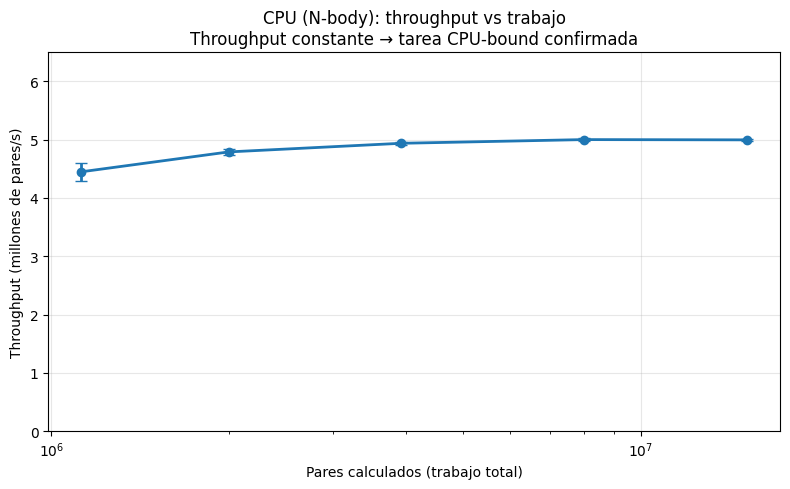

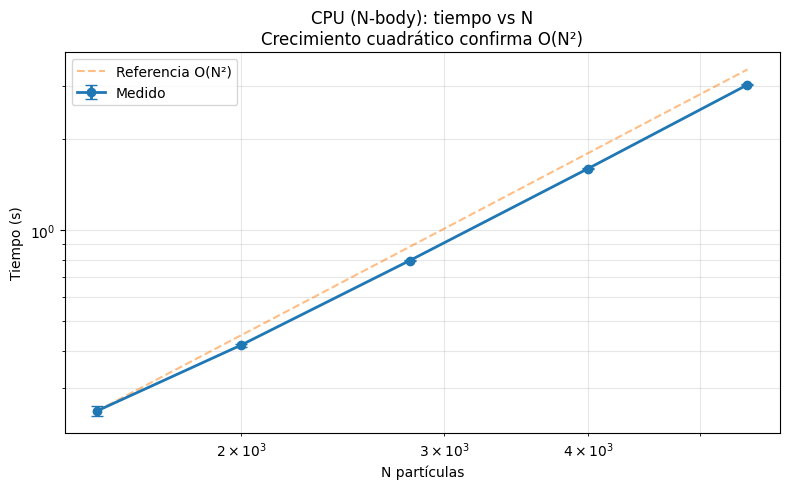

In [9]:
graficar_cpu(df_cpu)


**Conclusión:** El throughput se mantiene aproximadamente constante (~4.5-5.0 M 
pares/s) a lo largo de los 5 tamaños probados, con apenas ~12% de variación entre 
el menor y el mayor. Esa invariancia es la firma esperada de una tarea CPU-bound: 
el cuello de botella es la capacidad aritmética del procesador, no la memoria ni 
el almacenamiento. Las barras de error apenas visibles indican mediciones 
consistentes entre repeticiones, coherente con la efectividad del cooldown de 
10 s para mitigar thermal throttling.

La curva medida sigue prácticamente paralela a la referencia 
O(N²) en escala log-log, con la pendiente real ligeramente por debajo del ideal. 
Esto sugiere que la implementación se comporta consistentemente con el análisis 
asintótico del algoritmo N-body naive. La leve discrepancia respecto al ideal 
teórico (~10%) es atribuible al overhead constante del intérprete que no escala 
con N², y que pesa relativamente más en los tamaños chicos.

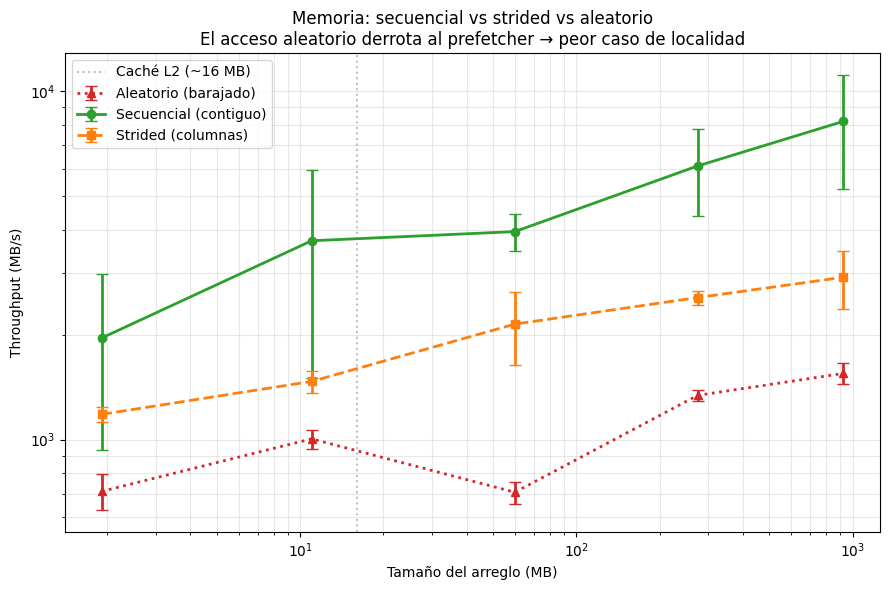

In [10]:
graficar_memoria(df_mem)


**Conclusión:** Los tres patrones de acceso quedan claramente ordenados en todo el 
rango medido: secuencial > strided > aleatorio. La brecha entre el acceso secuencial 
y el aleatorio crece de aproximadamente 2.8× (a 1.9 MB) hasta ~5.6× (a 60 MB) y se 
mantiene en torno a 5× en los tamaños mayores, pasando por la frontera de caché L2 
(~16 MB). Este comportamiento es consistente con la hipótesis de jerarquía de memoria: 
cuando el arreglo supera la capacidad de la caché, el acceso aleatorio sufre cache 
misses crecientes —al derrotar al prefetcher— mientras el secuencial sigue 
beneficiándose de la lectura contigua. Las barras de error amplias en el patrón 
secuencial para los tamaños chicos reflejan que sus tiempos, de apenas milisegundos, 
quedan dominados por el ruido del sistema operativo y no por la velocidad de memoria.

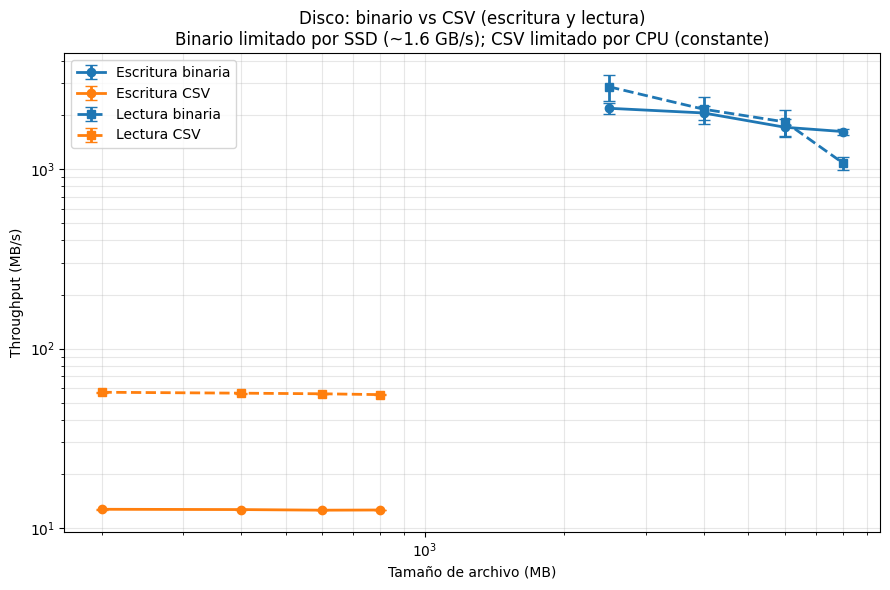

In [11]:
graficar_disco(df_disco)

**Conclusión:** Los dos pares de curvas (binario en azul, CSV en naranja) están 
separados por aproximadamente dos órdenes de magnitud. El binario opera entre 
1000-3000 MB/s y decae con el tamaño del archivo, convergiendo hacia el 
throughput sostenido del SSD para archivos grandes (≈ 1.6 GB/s en escritura). 
El CSV, en cambio, se mantiene plano independientemente del tamaño — firma de 
un proceso CPU-bound: la diferencia no es del dispositivo de almacenamiento 
sino del costo de serialización a texto. Esta observación justifica empíricamente 
la preferencia por formatos binarios columnares (Parquet) sobre CSV en pipelines 
Big Data, decisión adoptada en el Ejercicio 4 de esta evaluación.